In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, quad
from scipy.optimize import minimize
from scipy.interpolate import interp1d

#LOAD SNe DATA
url = 'https://raw.githubusercontent.com/dscolnic/Pantheon/master/lcparam_full_long.txt'
sne_data = pd.read_csv(url, sep='\s+')

sne_data = sne_data.sort_values(by='zcmb')
z_sne = sne_data['zcmb'].values
M_absolute = -19.36
mu_sne = sne_data['mb'].values - M_absolute
mu_error = sne_data['dmb'].values
print(f"Loaded {len(z_sne)} Supernovae.")

# LOAD BAO DATA (Extended Consensus: 6dFGS + SDSS MGS + BOSS + eBOSS)
z_bao = np.array([0.106, 0.15, 0.38, 0.51, 0.61, 0.70, 0.85, 1.52, 2.33])
dv_rs_data = np.array([2.98, 4.47, 10.23, 13.36, 15.51, 17.86, 19.50, 26.00, 31.22])
dv_rs_error = np.array([0.13, 0.16, 0.17, 0.21, 0.25, 0.33, 0.60, 1.15, 1.30])


# 3. THE ENGINE: RATRA-PEEBLES POTENTIAL

def get_Hubble_function(alpha, A, Omega_m0):
    #Solves the universe for V = A * phi^(-alpha)

    def V(phi): return A * (phi**(-alpha))
    def dV_dphi(phi): return -alpha * A * (phi**(-alpha - 1.0))

    def system(t, y):
        phi, phi_dot, a = y

        rho_m = Omega_m0 / (a**3)
        rho_phi = 0.5 * phi_dot**2 + V(phi)

        if rho_m + rho_phi <= 0: return [0, 0, 0]

        H = np.sqrt(rho_m + rho_phi)

        dphi_dt = phi_dot
        dphidot_dt = -3 * H * phi_dot - dV_dphi(phi)
        da_dt = a * H

        return [dphi_dt, dphidot_dt, da_dt]

    def stop_today(t, y): return y[2] - 1.0
    stop_today.terminal = True

    y0 = [1e-3, 0.0, 0.001]

    res = solve_ivp(system, [0, 100], y0, events=stop_today, max_step=0.05)

    phi_arr, phidot_arr, a_arr = res.y
    z_arr = (1.0 / a_arr) - 1.0

    rho_m_arr = Omega_m0 / (a_arr**3)
    rho_phi_arr = 0.5 * phidot_arr**2 + V(phi_arr)
    H_arr = np.sqrt(rho_m_arr + rho_phi_arr)

    H_interp = interp1d(z_arr[::-1], H_arr[::-1], kind='cubic', fill_value="extrapolate")
    return H_interp


# DISTANCES FOR SNE AND BAO

def calculate_theory(z_array_sne, z_array_bao, alpha, A, h0, Omega_m0):
    H_func = get_Hubble_function(alpha, A, Omega_m0)
    #NOte: z_array_sne and z_array_bao are fetched data z points
    # Calculate SNe Ia Observables (mu)
    mu_theory = []
    for z in z_array_sne:
        Dc, _ = quad(lambda x: 1.0 / H_func(x), 0, z)
        Dl = (1 + z) * Dc
        Dl_Mpc = Dl * (300000.0 / h0)
        mu = 5 * np.log10(Dl_Mpc) + 25
        mu_theory.append(mu)

    # Calculate BAO Observables (Dv/rs)
    bao_theory = []
    for z in z_array_bao:
        Dc, _ = quad(lambda x: 1.0 / H_func(x), 0, z)
        Dv = (z * (Dc**2) / H_func(z))**(1.0/3.0)

        rs_approx = 147.0 / (300000.0 / h0)
        bao_theory.append(Dv / rs_approx)

    return np.array(mu_theory), np.array(bao_theory)

#chi
def objective_chi2(params):
    alpha = params[0]
    A = params[1]
    Omega_m0 = params[2]
    h0 = 70.0

    mu_th, bao_th = calculate_theory(z_sne, z_bao, alpha, A, h0, Omega_m0)

    chi2_sne = np.sum(((mu_sne - mu_th) / mu_error)**2)
    chi2_bao = np.sum(((dv_rs_data - bao_th) / dv_rs_error)**2)

    return chi2_sne + chi2_bao

print("Starting 3-Parameter Fit (This will take a minute due to 1048 SNe points)...")
initial_guess = [0.5, 0.7, 0.3]
bounds = [(-0.01, 4.0), (0.01, 3.5), (0.01, 0.5)]

result = minimize(objective_chi2, initial_guess, bounds=bounds, method='L-BFGS-B')

print("\n--- RESULTS ---")
best_alpha = result.x[0]
best_A = result.x[1]
best_Om = result.x[2]
fixed_h0 = 70.0
min_chi2 = result.fun
best_M = best_A ** (1.0/ (4+best_alpha))

# Calculate Degrees of Freedom and Reduced Chi-Squared
num_data_points = len(z_sne) + len(z_bao)
num_parameters = 3
dof = num_data_points - num_parameters
reduced_chi2 = min_chi2 / dof

print(f"Best fit Alpha: {best_alpha:.6f}")
print(f"Best fit Amplitude (A): {best_M:.6f}")
print(f"Omega_m0: {best_Om:.4f}")
print(f"Total Chi2: {min_chi2:.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"Reduced Chi2: {reduced_chi2:.7f}")


textstr = '\n'.join((
    r'$\alpha=%.6f$' % (best_alpha, ),
    r'$M=%.6f$' % (best_M, ),
    r'$\Omega_{m0}=%.4f$' % (best_Om, ),
    r'$\chi^2_\nu=%.7f$' % (reduced_chi2, )))


props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')

# # --- PLOT 1: THE SNE FIT ---
# mu_plot, _ = calculate_theory(z_sne, [], best_alpha, best_A, fixed_h0, best_Om)

# fig1, ax1 = plt.subplots(figsize=(10, 6))
# ax1.scatter(z_sne, mu_sne, color='black', alpha=0.3, s=10, label='Pantheon Data')
# ax1.plot(z_sne, mu_plot, 'r-', linewidth=2, label=f'Ratra-Peebles Fit')
# ax1.set_xlabel('Redshift (z)')
# ax1.set_ylabel('Distance Modulus (mu)')
# ax1.set_title('Ratra-Peebles Quintessence Fit to Pantheon SNe Ia')
# ax1.legend(loc='upper left')
# ax1.grid(True)


# ax1.text(0.95, 0.05, textstr, transform=ax1.transAxes, fontsize=12,
#         verticalalignment='bottom', horizontalalignment='right', bbox=props)

# plt.savefig('SNe_Fit_RatraPeebles.png', dpi=300, bbox_inches='tight')
# plt.show()

# # --- PLOT 2: THE BAO DATA ---
# _, bao_plot_th = calculate_theory([], z_bao, best_alpha, best_A, fixed_h0, best_Om)

# fig2, ax2 = plt.subplots(figsize=(8, 5))
# ax2.errorbar(z_bao, dv_rs_data, yerr=dv_rs_error, fmt='ko', markersize=8, label='SDSS BAO Data')
# ax2.plot(z_bao, bao_plot_th, 'rX', markersize=12, label='Ratra-Peebles Theory')
# ax2.set_xlabel('Redshift (z)')
# ax2.set_ylabel('Volume Distance Ratio (Dv / rs)')
# ax2.set_title('Ratra-Peebles Fit to BAO Observables')
# ax2.legend(loc='upper left')
# ax2.grid(True)


# ax2.text(0.95, 0.05, textstr, transform=ax2.transAxes, fontsize=12,
#         verticalalignment='bottom', horizontalalignment='right', bbox=props)

# plt.savefig('BAO_Fit_RatraPeebles.png', dpi=300, bbox_inches='tight')
# plt.show()



<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_505/191692927.py:10: SyntaxWarning: invalid escape sequence '\s'
  sne_data = pd.read_csv(url, sep='\s+')


Loaded 1048 Supernovae.
Starting 3-Parameter Fit (This will take a minute due to 1048 SNe points)...


/tmp/ipykernel_505/191692927.py:30: RuntimeWarning: invalid value encountered in scalar power
  def V(phi): return A * (phi**(-alpha))
/tmp/ipykernel_505/191692927.py:31: RuntimeWarning: invalid value encountered in scalar power
  def dV_dphi(phi): return -alpha * A * (phi**(-alpha - 1.0))
/tmp/ipykernel_505/191692927.py:78: RuntimeWarning: invalid value encountered in log10
  mu = 5 * np.log10(Dl_Mpc) + 25
/tmp/ipykernel_505/191692927.py:85: RuntimeWarning: invalid value encountered in scalar power
  Dv = (z * (Dc**2) / H_func(z))**(1.0/3.0)



--- RESULTS ---
Best fit Alpha: 0.000257
Best fit Amplitude (A): 0.930121
Omega_m0: 0.2543
Total Chi2: 1094.90
Degrees of Freedom: 1054
Reduced Chi2: 1.0388087


In [2]:
H_funcc = get_Hubble_function(best_alpha, best_A, best_Om)
print(H_funcc(0))

1.001821533174032


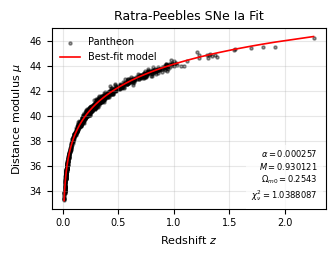

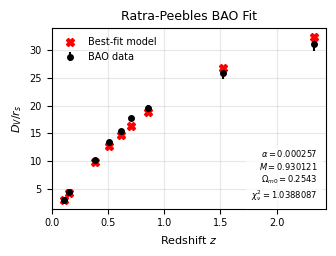

In [3]:

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

# --- PLOT 1: SNe ---
mu_plot, _ = calculate_theory(z_sne, [], best_alpha, best_A, fixed_h0, best_Om)

fig1, ax1 = plt.subplots(figsize=(3.4, 2.6))

ax1.scatter(z_sne, mu_sne, color='black', alpha=0.4, s=5, label='Pantheon')
ax1.plot(z_sne, mu_plot, 'r-', linewidth=1.2, label='Best-fit model')

ax1.set_xlabel('Redshift $z$')
ax1.set_ylabel('Distance modulus $\\mu$')
ax1.set_title('Ratra-Peebles SNe Ia Fit')
ax1.legend(loc='upper left', frameon=False)
ax1.grid(True, alpha=0.3)

ax1.text(0.97, 0.03, textstr, transform=ax1.transAxes,
         fontsize=6, verticalalignment='bottom',
         horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.savefig('SNeRatraPeebles.pdf', dpi=500)
# plt.savefig('SNe_Fit_RatraPeebles.png', dpi=500)
plt.show()


# --- PLOT 2: BAO  ---
_, bao_plot_th = calculate_theory([], z_bao, best_alpha, best_A, fixed_h0, best_Om)

fig2, ax2 = plt.subplots(figsize=(3.4, 2.6))

ax2.errorbar(z_bao, dv_rs_data, yerr=dv_rs_error,
             fmt='ko', markersize=4, label='BAO data')

ax2.plot(z_bao, bao_plot_th, 'rX', markersize=6, label='Best-fit model')

ax2.set_xlabel('Redshift $z$')
ax2.set_ylabel('$D_V / r_s$')
ax2.set_title('Ratra-Peebles BAO Fit')
ax2.legend(loc='upper left', frameon=False)
ax2.grid(True, alpha=0.3)

ax2.text(0.97, 0.03, textstr, transform=ax2.transAxes,
         fontsize=6, verticalalignment='bottom',
         horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.savefig('BAORatraPeebles.pdf', dpi=500)
# plt.savefig('BAO_Fit_RatraPeebles.png', dpi=500)
plt.show()

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, quad, cumulative_simpson
from scipy.optimize import minimize
from scipy.interpolate import interp1d

#LOAD SNe DATA
url = 'https://raw.githubusercontent.com/dscolnic/Pantheon/master/lcparam_full_long.txt'
sne_data = pd.read_csv(url, sep='\s+')

sne_data = sne_data.sort_values(by='zcmb')
z_sne = sne_data['zcmb'].values
M_absolute = -19.36
mu_sne = sne_data['mb'].values - M_absolute
mu_error = sne_data['dmb'].values
print(f"Loaded {len(z_sne)} Supernovae.")

# LOAD BAO DATA (Extended Consensus: 6dFGS + SDSS MGS + BOSS + eBOSS)
z_bao = np.array([0.106, 0.15, 0.38, 0.51, 0.61, 0.70, 0.85, 1.52, 2.33])
dv_rs_data = np.array([2.98, 4.47, 10.23, 13.36, 15.51, 17.86, 19.50, 26.00, 31.22])
dv_rs_error = np.array([0.13, 0.16, 0.17, 0.21, 0.25, 0.33, 0.60, 1.15, 1.30])


# 3. THE ENGINE: RATRA-PEEBLES POTENTIAL

def get_Hubble_function(f, MU, Omega_m0):
    #Solves the universe for V = A * phi^(-alpha)


    def V(phi): return (MU**4) * (1.0 + np.cos(phi / f))
    def dV_dphi(phi): return -( (MU**4) / f ) * np.sin(phi / f)

    def system(t, y):
        phi, phi_dot, a = y

        rho_m = Omega_m0 / (a**3)
        rho_phi = 0.5 * phi_dot**2 + V(phi)

        if rho_m + rho_phi <= 0: return [0, 0, 0]

        H = np.sqrt(rho_m + rho_phi)

        dphi_dt = phi_dot
        dphidot_dt = -3 * H * phi_dot - dV_dphi(phi)
        da_dt = a * H

        return [dphi_dt, dphidot_dt, da_dt]

    def stop_today(t, y): return y[2] - 1.0
    stop_today.terminal = True

    y0 = [0.2 * f, 0.0, 0.001]

    # FIX 1 & 2: Increase max time to 1000 to ensure a=1 is reached.
    # FIX 3: Use 'Radau' for stiff equations and remove 'max_step'.
    res = solve_ivp(system, [0, 1000], y0, events=stop_today, method='Radau', rtol=1e-4, atol=1e-6)

    # FIX 4: If the universe fails to reach a=1.0, explicitly throw an error
    # so the try/except block in objective_chi2 can penalize this parameter guess.
    if len(res.t_events[0]) == 0:
        raise ValueError("Universe did not reach a=1.0")

    phi_arr, phidot_arr, a_arr = res.y

    # print(f"Initial phi: {phi_arr[0]:.6f} | Final phi today: {phi_arr[-1]:.6f}")

    z_arr = (1.0 / a_arr) - 1.0

    rho_m_arr = Omega_m0 / (a_arr**3)
    rho_phi_arr = 0.5 * phidot_arr**2 + V(phi_arr)
    H_arr = np.sqrt(rho_m_arr + rho_phi_arr)

    # Reverse arrays
    z_rev = z_arr[::-1]
    H_rev = H_arr[::-1]

    # Remove duplicates in z
    z_unique, indices = np.unique(z_rev, return_index=True)
    H_unique = H_rev[indices]

    # Interpolate
    H_interp = interp1d(z_unique, H_unique, kind='cubic', fill_value="extrapolate")
    return H_interp


# DISTANCES FOR SNE AND BAO

# def calculate_theory(z_array_sne, z_array_bao, f, MU, h0, Omega_m0):
#     H_func = get_Hubble_function(f, MU, Omega_m0)
#     #NOte: z_array_sne and z_array_bao are fetched data z points
#     # Calculate SNe Ia Observables (mu)
#     mu_theory = []
#     for z in z_array_sne:
#         Dc, _ = quad(lambda x: 1.0 / H_func(x), 0, z)
#         Dl = (1 + z) * Dc
#         Dl_Mpc = Dl * (300000.0 / h0)
#         mu = 5 * np.log10(Dl_Mpc) + 25
#         mu_theory.append(mu)

#     # Calculate BAO Observables (Dv/rs)
#     bao_theory = []
#     for z in z_array_bao:
#         Dc, _ = quad(lambda x: 1.0 / H_func(x), 0, z)
#         Dv = (z * (Dc**2) / H_func(z))**(1.0/3.0)

#         rs_approx = 147.0 / (300000.0 / h0)
#         bao_theory.append(Dv / rs_approx)

#     return np.array(mu_theory), np.array(bao_theory)
# DISTANCES FOR SNE AND BAO

def calculate_theory(z_array_sne, z_array_bao, f, MU, h0, Omega_m0):
    H_func = get_Hubble_function(f, MU, Omega_m0)

    z_sne_arr = np.array(z_array_sne)
    z_bao_arr = np.array(z_array_bao)

    # 1. Determine the maximum z needed for the grid (handle empty arrays for plotting)
    if z_sne_arr.size > 0 and z_bao_arr.size > 0:
        z_max = max(np.max(z_sne_arr), np.max(z_bao_arr)) + 0.1
    elif z_sne_arr.size > 0:
        z_max = np.max(z_sne_arr) + 0.1
    elif z_bao_arr.size > 0:
        z_max = np.max(z_bao_arr) + 0.1
    else:
        return np.array([]), np.array([])

    # 2. Create dense grid and evaluate H(z)
    # Using 1001 points (odd number is required for Simpson's rule)
    z_grid = np.linspace(0, z_max, 1001)
    H_grid = H_func(z_grid)

    # 3. Integrate ONCE using cumulative_simpson for smooth parabolic fitting
    Dc_grid = cumulative_simpson(1.0 / H_grid, x=z_grid, initial=0)

    # 4. Create interpolator
    Dc_func = interp1d(z_grid, Dc_grid, kind='cubic', fill_value="extrapolate")

    # --- Vectorized Calculation for SNe Ia ---
    if z_sne_arr.size > 0:
        Dc_sne = Dc_func(z_sne_arr)
        Dl_sne = (1 + z_sne_arr) * Dc_sne
        Dl_Mpc = Dl_sne * (300000.0 / h0)
        mu_theory = 5 * np.log10(Dl_Mpc) + 25
    else:
        mu_theory = np.array([])

    # --- Vectorized Calculation for BAO ---
    if z_bao_arr.size > 0:
        Dc_bao = Dc_func(z_bao_arr)
        H_bao = H_func(z_bao_arr)
        Dv_bao = (z_bao_arr * (Dc_bao**2) / H_bao)**(1.0/3.0)

        rs_approx = 147.0 / (300000.0 / h0)
        bao_theory = Dv_bao / rs_approx
    else:
        bao_theory = np.array([])

    return mu_theory, bao_theory

#chi
# def objective_chi2(params):
#     f = params[0]
#     MU = params[1]
#     Omega_m0 = params[2]
#     h0 = 70.0

#     mu_th, bao_th = calculate_theory(z_sne, z_bao, f, MU, h0, Omega_m0)

#     chi2_sne = np.sum(((mu_sne - mu_th) / mu_error)**2)
#     chi2_bao = np.sum(((dv_rs_data - bao_th) / dv_rs_error)**2)

#     return chi2_sne + chi2_bao

def objective_chi2(params):
    f = params[0]
    MU = params[1]
    Omega_m0 = params[2]
    h0 = 70.0

    try:
        mu_th, bao_th = calculate_theory(z_sne, z_bao, f, MU, h0, Omega_m0)

        chi2_sne = np.sum(((mu_sne - mu_th) / mu_error)**2)
        chi2_bao = np.sum(((dv_rs_data - bao_th) / dv_rs_error)**2)

        return chi2_sne + chi2_bao
    except Exception:
        # If the parameter guess causes ODE failure or math errors,
        # return a high penalty to push L-BFGS-B away.
        return 1e10

print("Starting 3-Parameter Fit (This will take a minute due to 1048 SNe points)...")
initial_guess = [2.0, 0.9, 0.3]
bounds = [(0.01, 4.0), (0.01, 5.0), (0.2, 0.5)]

result = minimize(objective_chi2, initial_guess, bounds=bounds, method='L-BFGS-B')

print("\n--- RESULTS ---")
best_f = result.x[0]
best_MU = result.x[1]
best_Om = result.x[2]
fixed_h0 = 70.0
min_chi2 = result.fun


# Calculate Degrees of Freedom and Reduced Chi-Squared
num_data_points = len(z_sne) + len(z_bao)
num_parameters = 3
dof = num_data_points - num_parameters
reduced_chi2 = min_chi2 / dof

print(f"Best fit f: {best_f:.6f}")
print(f"Best fit MU: {best_MU:.6f}")
print(f"Omega_m0: {best_Om:.4f}")
print(f"Total Chi2: {min_chi2:.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"Reduced Chi2: {reduced_chi2:.7f}")


textstr = '\n'.join((
    r'$f=%.7f$' % (best_f, ),
    r'$M=%.7f$' % (best_MU, ),
    r'$\Omega_{m0}=%.4f$' % (best_Om, ),
    r'$\chi^2_\nu=%.7f$' % (reduced_chi2, )))


props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')

# # --- PLOT 1: THE SNE FIT ---
# mu_plot, _ = calculate_theory(z_sne, [], best_alpha, best_A, fixed_h0, best_Om)

# fig1, ax1 = plt.subplots(figsize=(10, 6))
# ax1.scatter(z_sne, mu_sne, color='black', alpha=0.3, s=10, label='Pantheon Data')
# ax1.plot(z_sne, mu_plot, 'r-', linewidth=2, label=f'PNGB Fit')
# ax1.set_xlabel('Redshift (z)')
# ax1.set_ylabel('Distance Modulus (mu)')
# ax1.set_title('Ratra-Peebles Quintessence Fit to Pantheon SNe Ia')
# ax1.legend(loc='upper left')
# ax1.grid(True)


# ax1.text(0.95, 0.05, textstr, transform=ax1.transAxes, fontsize=12,
#         verticalalignment='bottom', horizontalalignment='right', bbox=props)

# # plt.savefig('SNe_Fit_RatraPeebles.png', dpi=300, bbox_inches='tight')
# plt.show()

# # --- PLOT 2: THE BAO DATA ---
# _, bao_plot_th = calculate_theory([], z_bao, best_alpha, best_A, fixed_h0, best_Om)

# fig2, ax2 = plt.subplots(figsize=(8, 5))
# ax2.errorbar(z_bao, dv_rs_data, yerr=dv_rs_error, fmt='ko', markersize=8, label='SDSS BAO Data')
# ax2.plot(z_bao, bao_plot_th, 'rX', markersize=12, label='Ratra-Peebles Theory')
# ax2.set_xlabel('Redshift (z)')
# ax2.set_ylabel('Volume Distance Ratio (Dv / rs)')
# ax2.set_title('Ratra-Peebles Fit to BAO Observables')
# ax2.legend(loc='upper left')
# ax2.grid(True)


# ax2.text(0.95, 0.05, textstr, transform=ax2.transAxes, fontsize=12,
#         verticalalignment='bottom', horizontalalignment='right', bbox=props)

# # plt.savefig('BAO_Fit_RatraPeebles.png', dpi=300, bbox_inches='tight')
# plt.show()



<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_505/2919949855.py:10: SyntaxWarning: invalid escape sequence '\s'
  sne_data = pd.read_csv(url, sep='\s+')


Loaded 1048 Supernovae.
Starting 3-Parameter Fit (This will take a minute due to 1048 SNe points)...

--- RESULTS ---
Best fit f: 1.734062
Best fit MU: 0.784779
Omega_m0: 0.2535
Total Chi2: 1094.88
Degrees of Freedom: 1054
Reduced Chi2: 1.0387813


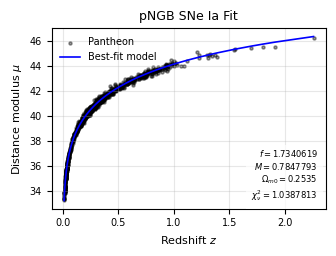

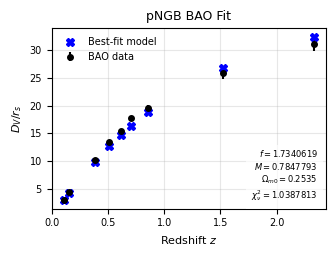

In [5]:
# Common plotting style (important for consistency)
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

# --- PLOT 1: SNe (Single-column size) ---
mu_plot, _ = calculate_theory(z_sne, [], best_f, best_MU, fixed_h0, best_Om)

fig1, ax1 = plt.subplots(figsize=(3.4, 2.6))

ax1.scatter(z_sne, mu_sne, color='black', alpha=0.4, s=5, label='Pantheon')
ax1.plot(z_sne, mu_plot, 'b-', linewidth=1.2, label='Best-fit model')

ax1.set_xlabel('Redshift $z$')
ax1.set_ylabel('Distance modulus $\\mu$')
ax1.set_title('pNGB SNe Ia Fit')
ax1.legend(loc='upper left', frameon=False)
ax1.grid(True, alpha=0.3)

ax1.text(0.97, 0.03, textstr, transform=ax1.transAxes,
         fontsize=6, verticalalignment='bottom',
         horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.savefig('SNePNGB.pdf', dpi=500)
# plt.savefig('SNe_Fit_RatraPeebles.png', dpi=500)
plt.show()


# --- PLOT 2: BAO (Single-column size) ---
_, bao_plot_th = calculate_theory([], z_bao, best_f, best_MU, fixed_h0, best_Om)

fig2, ax2 = plt.subplots(figsize=(3.4, 2.6))

ax2.errorbar(z_bao, dv_rs_data, yerr=dv_rs_error,
             fmt='ko', markersize=4, label='BAO data')

ax2.plot(z_bao, bao_plot_th, 'bX', markersize=6, label='Best-fit model')

ax2.set_xlabel('Redshift $z$')
ax2.set_ylabel('$D_V / r_s$')
ax2.set_title('pNGB BAO Fit')
ax2.legend(loc='upper left', frameon=False)
ax2.grid(True, alpha=0.3)

ax2.text(0.97, 0.03, textstr, transform=ax2.transAxes,
         fontsize=6, verticalalignment='bottom',
         horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.savefig('BAOPNGB.pdf', dpi=500)
# plt.savefig('BAO_Fit_RatraPeebles.png', dpi=500)
plt.show()